# 0.0 Установка # Обновление пакета geomml 

In [1]:
from pathlib import Path
import os

root = Path(os.getcwd()).resolve().parents[1]  # вверх на 2 уровня
!python {str(root / "scripts" / "bootstrap.py")}

%load_ext autoreload
%autoreload 2

from hydra import initialize_config_dir, compose
from hydra.utils import instantiate

config_name = "default"

with initialize_config_dir(config_dir=str(root / "configs"), version_base="1.3"):
    cfg = compose(config_name=config_name)

Obtaining file:///C:/Users/goryachev/source/repos/DLS/_Sem_01/project-GeomML
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for geomml (pyproject.toml): started
  Building editable for geomml (pyproject.toml): finished with status 'done'
  Created wheel for geomml: filename=geomml-0.1-0.editable-py3-none-any.whl size=1273 sha256=95b3bc3481e0f15869ed0fcece833faee95a7d148c1f2aec3171c5ce29e22657
  Stored in directory: C:\Users\goryachev\AppData\Local\Temp\pip-ephem-wheel-cache-3652uyl8\wheels\0f\c4\38\dccd6c4acc97c3521a749adbb62

# 0.1 Импорт необходимых модулей # библиотек

In [2]:
import torch, os
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch

from geomml.models import build as build_model
from geomml.datasets import build as build_dataset
from geomml.losses.kendall import * 
from geomml.utils.loader import build as build_loaders
from geomml.utils.plot_history import *
from geomml.trainers.multi_task import MultiTaskTrainer
from geomml.trainers.evaluate_model import *


N_EPOCHS=1000

# 0.2 Получение информации о QM9S dataset
QM9Spectra(QM9S) dataset using 130K organic molecules based on the popular QM9 dataset. 

Two versions of the dataset, .pt (torch_geometric version) and .csv, are provided for training and use. In addition, we also provide broadened spectra.

Sources: 
* https://figshare.com/articles/dataset/QM9S_dataset/24235333
* DOI: https://doi.org/10.1038/s43588-023-00550-y



In [3]:
DATA = "data"
dataset  = torch.load(os.path.join(DATA, "qm9s.pt"), map_location="cpu")
sample = dataset[0]

print(type(sample))
print(sample)
print(sample.dipole.shape)
print(sample.polar.shape)

print(type(dataset ))

print(type(dataset))
print(len(dataset))

print("\n==========================================")

all_polar = []
for data in dataset:
    all_polar.append(data.polar.view(-1))
all_polar = torch.cat(all_polar)
print("polar min:", all_polar.min())
print("polar max:", all_polar.max())
print("polar mean:", all_polar.mean())
print("polar std:", all_polar.std())

all_dipole = []
for data in dataset:
    all_dipole.append(data.dipole.view(-1))
all_dipole = torch.cat(all_dipole)
print("dipole min:", all_dipole.min())
print("dipole max:", all_dipole.max())
print("dipole mean:", all_dipole.mean())
print("dipole std:", all_dipole.std())

del dataset

<class 'torch_geometric.data.data.Data'>
Data(edge_index=[2, 20], pos=[5, 3], number=1, smile='C', z=[5], quadrupole=[1, 3, 3], octapole=[1, 3, 3, 3], npacharge=[5], dipole=[1, 3], polar=[1, 3, 3], hyperpolar=[1, 3, 3, 3], energy=[1, 1], Hij=[20, 3, 3], Hi=[5, 3, 3], dedipole=[5, 3, 3], depolar=[5, 3, 6], tran_dipole=[1, 10, 3], tran_energy=[1, 10])
torch.Size([1, 3])
torch.Size([1, 3, 3])
<class 'list'>
<class 'list'>
129817

polar min: tensor(-113.3840)
polar max: tensor(361.1190)
polar mean: tensor(27.4076)
polar std: tensor(39.7725)
dipole min: tensor(-8.5813)
dipole max: tensor(10.0062)
dipole mean: tensor(0.1989)
dipole std: tensor(1.8607)


1. GeomML-признаки:
* SOAP (DScribe), 
* ACSF, 
* MBTR, 
* Coulomb Matrix 
* эмбеддинги уже существующей модели GeomML?

2. TDA:
* Persistence Diagram;
* Persistence Image;
* Persistence Landscape;
* Betti Curve.

# 0.3 Предобработка исходного QM9S датасета перед обучением модели
```python
qm9s.pt
   |
   |  Data
   |
   |  + добавляем x
   |  + меняем dipole
   |  + меняем polar
   |  + меняем класс Data -> QM9SData
   |
   ↓
qm9s_processed.pt

QM9SData:
    z
    pos
    edge_index
    x          [N_atoms,5]
    dipole     [1,3]
    polar      [1,9]
```

In [4]:
src=os.path.join(DATA,"qm9s.pt")
out=os.path.join(DATA,"qm9s_processed.pt")

if not os.path.exists(out):
    !python {str(root / "scripts" / "preprocess_qm9s.py")} {src} {out}
else:
    print(f"Already exists: {out}")

dataset=build_dataset(
    name="qm9s",
    root=os.path.join(DATA, "qm9s_processed.pt"),
    normalize=True
)
loaders=build_loaders( dataset, batch_size=64 )

Already exists: data\qm9s_processed.pt

Dataset size: 129817



# 0.4 Проверка перед запуском обучения

In [5]:
batch=next(iter(loaders.train))
model=build_model(name="qm9s_dimenet")
out=model(batch)

print(out["dipole"].shape)
print(out["polar"].shape)

torch.Size([64, 3])
torch.Size([64, 9])


In [6]:
data_qm9s_processed=torch.load("data/qm9s_processed.pt", map_location="cpu")

print(data_qm9s_processed[0].dipole.shape)
print(data_qm9s_processed[0].polar.shape)

torch.Size([1, 3])
torch.Size([1, 9])


In [7]:
from torch_geometric.data import Batch

b=Batch.from_data_list(
    data_qm9s_processed[:64]
)

print(type(b))
print(b.dipole.shape)
print(b.polar.shape)

<class 'abc.QM9SDataBatch'>
torch.Size([64, 1, 3])
torch.Size([64, 1, 9])


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch=next(iter(loaders.train))

print(type(batch))
print(type(batch.dipole))
print(batch.dipole.shape)
print(batch.polar.shape)
print(type(data_qm9s_processed[0]))

batch=batch.to(device)
model=model.to(device)
out=model(batch)
loss=model.loss_fn(out,batch)

print(out["dipole"].shape)
print(out["polar"].shape)
print(loss)

<class 'abc.QM9SDataBatch'>
<class 'torch.Tensor'>
torch.Size([64, 1, 3])
torch.Size([64, 1, 9])
<class 'geomml.datasets.qm9s.QM9SData'>
torch.Size([64, 3])
torch.Size([64, 9])
tensor(2.1403, device='cuda:0', grad_fn=<AddBackward0>)


In [9]:
batch=next(iter(loaders.train))

print(batch.dipole.shape)
print(batch.polar.shape)

del loaders, out, model, batch, data_qm9s_processed


torch.Size([64, 1, 3])
torch.Size([64, 1, 9])


# 1. Постановка задачи

Улучшение предсказаний вектора дипольного момента и тензора поляризуемости молекул датасета [QM9s](https://figshare.com/articles/dataset/QM9S_dataset/24235333) с использованием GeomML + TDA

# 2. Описание Модели

# 3. Обучение на QM9s dataset c default loss

Здесь и далее в экспериментах будут применяться параметры для optimizer и scheduler из default-конфигов в директории `configs`. Конкретно, это:
```python
optimizer = AdamW (
      lr: 3e-4
      weight_decay: 1e-5
)
```
и
```python
scheduler = ReduceLROnPlateau (
    mode: min       # минимизируем val_mse
    factor: 0.5     # уменьшить LR в 2 раза
    patience: 3     # если 3 эпохи нет улучшения
    min_lr: 1e-6
)
```



Dataset size: 129817

Epoch [   1/1000] | TrainLoss: 1.776332 | ValidLoss: 1.700159 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 78.89s | Best Model State was Saved
Epoch [   2/1000] | TrainLoss: 1.616190 | ValidLoss: 1.562197 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 79.06s | Best Model State was Saved
Epoch [   3/1000] | TrainLoss: 1.524571 | ValidLoss: 1.467225 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 80.26s | Best Model State was Saved
Epoch [   4/1000] | TrainLoss: 1.441745 | ValidLoss: 1.405717 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 81.29s | Best Model State was Saved
Epoch [   5/1000] | TrainLoss: 1.369620 | ValidLoss: 1.336338 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 79.42s | Best Model State was Saved
Epoch [   6/1000] | TrainLoss: 1.307119 | ValidLoss: 1.254000 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 79.88s | Best Model State was Saved
Epoch [   7/1000] | TrainLoss: 1.243251 | ValidLoss: 1.220225 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime

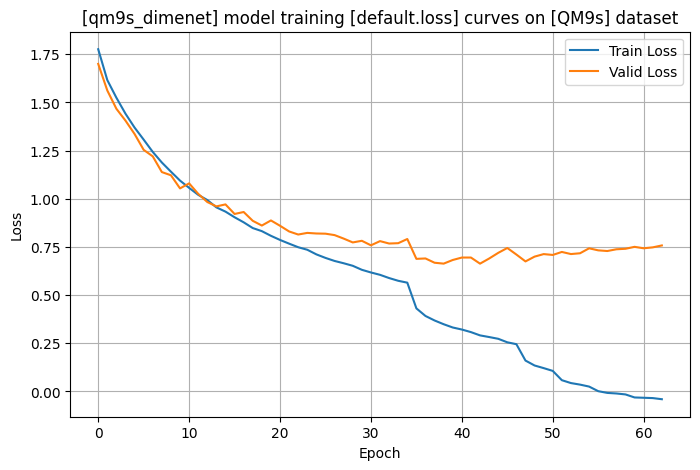

{'dipole': {'MAE': 0.5222254, 'RMSE': 0.71273875}, 'polar': {'MAE': 0.48621336, 'RMSE': 0.7083072}}


In [10]:
loaders=build_loaders( dataset, batch_size=32, train_size=0.8, valid_size=0.1)
model=build_model( "qm9s_dimenet", hidden_dim=256, layers=4 )
optimizer=instantiate( cfg.optimizer, params=model.parameters() )
scheduler=instantiate( cfg.scheduler, optimizer )

model,history=MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    patience=20,
    min_delta=1e-4,
    checkpoint_name="best_qm9s_dimenet",
).fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=N_EPOCHS
)

plot_history(history, title="[qm9s_dimenet] model training [default.loss] curves on [QM9s] dataset")
print( evaluate_qm9s( model, loaders.test, device ) )

del model, loaders, optimizer, history, scheduler

## Наблюдения
```python
1. Отношения метрик:
```
* **Dipol**: $RMSE / MAE ≈ 1.36$
* **Polar**: $RMSE / MAE ≈ 1.46$


```python
2. log_vars.data = tensor([0.1444, 3.2770])
```
То есть модель почти полностью оптимизирует dipole, а polar почти игнорирует.
* **Dipole**: `log_var = 0.1444` -> `exp(-0.1444) = 0.866` -> то есть `dipole weight ≈ 0.87`.
* **Polar**: `log_var = 3.277` -> `exp(-3.277) = 0.0377` -> то есть `polar weight ≈ 0.038`

Получаем очень сильное подавление. Это не обязательно ошибка — **uncertainty weighting** именно так и работает, если одна задача сложнее/шумнее.

Также, глядя на метрики из пункта 1, можно заключить, что модель сама "увидела": задача dipole - легче, а polar - сложнее, - и сделала:
* weight(dipole) ≈ 0.87
* weight(polar)  ≈ 0.038

Модель почти отказалась оптимизировать polar. Попробуем заменить на кастомный **Kendall loss**, который адаптирует веса под задачу. 

# 4. Обучение на QM9s dataset c Kendall loss

### Формула Kendall loss для regression задач:
$$
L = \frac{1}{2\sigma^2} L_i + \log \sigma
$$
#### Источник: Kendall et al., Multi-Task Learning Using Uncertainty to Weigh Losses

Каждая задача получает вес:
$$
w_i = exp(−log σ_i^2),
$$

В итоге это даёт следующее:
* σ обучается вместе с моделью
* модель сама решает, какую задачу “сложно” учить, а какую “дешево” оптимизировать
* динамические веса,
* адаптация под датасет,

то есть лучше баланс, меньше ручной настройки, smoother convergence.


Dataset size: 129817

Epoch [   1/1000] | TrainLoss: 0.892896 | ValidLoss: 0.839765 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 73.85s | Best Model State was Saved
Epoch [   2/1000] | TrainLoss: 0.812728 | ValidLoss: 0.777556 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 73.94s | Best Model State was Saved
Epoch [   3/1000] | TrainLoss: 0.758821 | ValidLoss: 0.726704 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 74.19s | Best Model State was Saved
Epoch [   4/1000] | TrainLoss: 0.713098 | ValidLoss: 0.698318 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 73.95s | Best Model State was Saved
Epoch [   5/1000] | TrainLoss: 0.676017 | ValidLoss: 0.652470 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 74.08s | Best Model State was Saved
Epoch [   6/1000] | TrainLoss: 0.641311 | ValidLoss: 0.620597 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 74.26s | Best Model State was Saved
Epoch [   7/1000] | TrainLoss: 0.609253 | ValidLoss: 0.596531 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime

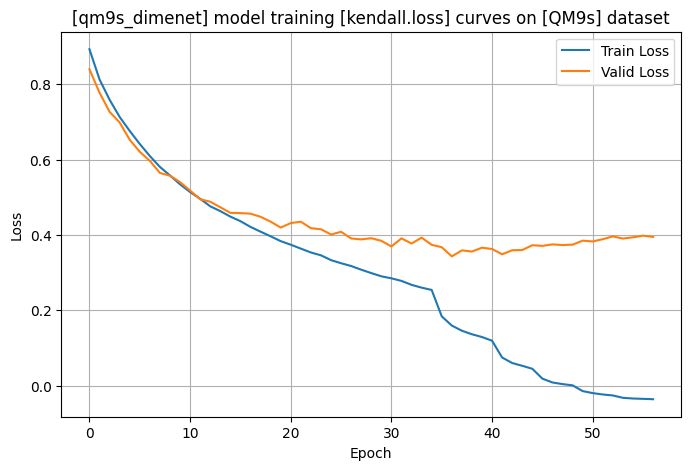

{'dipole': {'MAE': 0.5109729, 'RMSE': 0.6982398}, 'polar': {'MAE': 0.4835393, 'RMSE': 0.69636714}}


In [11]:
from geomml.losses.kendall import * 

loaders=build_loaders( dataset, batch_size=32, train_size=0.8, valid_size=0.1)
model=build_model( "qm9s_dimenet", hidden_dim=256, layers=4 )
optimizer=instantiate( cfg.optimizer, params=model.parameters() )
scheduler=instantiate( cfg.scheduler, optimizer )

model,history=MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion = kendall_loss, # используем кастомный лосс из 'geomml/losses/kendall.py'
    patience=20,
    min_delta=1e-4,
    checkpoint_name="best_qm9s_dimenet_kendall",
).fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=N_EPOCHS
)

plot_history(history, title="[qm9s_dimenet] model training [kendall.loss] curves on [QM9s] dataset")
print( evaluate_qm9s( model, loaders.test, device ) )

del model, loaders, optimizer, history, scheduler

# 5. Заключение